# Embedded Feature Selection

Let us see embedded feature selection methods using the Telco Churn dataset. Unlike filter and wrapper methods, embedded approaches perform feature selection as part of the model training process.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

Load the pre-cleaned data `'telco_churn_cleaned.parquet'`

In [2]:
df = pd.read_parquet('./datasets/telco_churn_cleaned.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   object  
 1   gender            7032 non-null   category
 2   SeniorCitizen     7032 non-null   int64   
 3   Partner           7032 non-null   category
 4   Dependents        7032 non-null   category
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   category
 7   MultipleLines     7032 non-null   category
 8   InternetService   7032 non-null   category
 9   OnlineSecurity    7032 non-null   category
 10  OnlineBackup      7032 non-null   category
 11  DeviceProtection  7032 non-null   category
 12  TechSupport       7032 non-null   category
 13  StreamingTV       7032 non-null   category
 14  StreamingMovies   7032 non-null   category
 15  Contract          7032 non-null   category
 16  PaperlessBilling  7032 non-nu

In [3]:
# define features and target
y = (df["Churn"] == "Yes").astype(int)
X = df.drop(columns=["Churn", "customerID"])
X.shape, y.shape

((7032, 19), (7032,))

### Data Transformation Pipeline and Splitting

In [4]:
numeric_features = X.select_dtypes(include=["int", "float"]).columns
categorical_features = X.select_dtypes(include=["category"]).columns

# setting up pipeline 
preprocess = ColumnTransformer(
    transformers=[("num", StandardScaler(), numeric_features),("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)]
)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

### L1-Regularised Logistic Regression

L1 penalty encourages sparsity, so coefficients may become zero. Features with non-zero weights are considered important contributors.

In [6]:
logreg_l1 = Pipeline([("preprocess", preprocess),
                      ("model", LogisticRegression(penalty="l1", solver="liblinear", max_iter=200))])

logreg_l1.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [7]:
# Retrieve final feature names after one-hot encoding 
ohe = logreg_l1.named_steps["preprocess"].named_transformers_["cat"]
ohe_features = ohe.get_feature_names_out(categorical_features)

all_features = np.concatenate([numeric_features, ohe_features])

# Coefficients from classifier
coef = logreg_l1.named_steps["model"].coef_.flatten()

selected_l1 = all_features[coef != 0]

l1_df = pd.DataFrame({"Feature": selected_l1,"Coefficient": coef[coef != 0]}).sort_values("Coefficient", key=abs, ascending=False)
l1_df

,Feature,Coefficient
28,Contract_Two year,-1.615234
1,tenure,-1.488583
22,StreamingTV_No internet service,-1.094971
2,TotalCharges,0.726314
27,Contract_One year,-0.695633
8,InternetService_DSL,-0.503572
6,PhoneService_Yes,-0.408284
29,PaperlessBilling_No,-0.342372
14,OnlineBackup_No internet service,-0.322176
9,InternetService_Fiber optic,0.299869


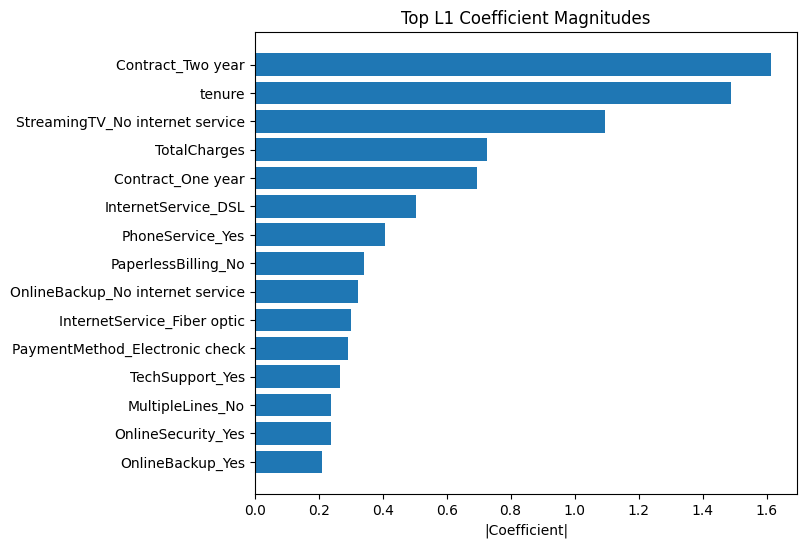

In [8]:
plt.figure(figsize=(7,6))
plt.barh(l1_df["Feature"].head(15), abs(l1_df["Coefficient"].head(15)))
plt.gca().invert_yaxis()
plt.title("Top L1 Coefficient Magnitudes")
plt.xlabel("|Coefficient|")
plt.show()

Here, a larger magnitude of feature coefficient means stronger influence on predicting churn.

Only non-zero coefficients remain after applying the L1 penalty. Features with stronger magnitude values are more influential for churn prediction. However, importance here reflects a purely linear relationship, interactions and non-linear effects may not be captured.

### Random Forest Feature Importances

Tree-based models capture non-linearities and interactions and provide feature contributions via impurity reduction

In [9]:
rf_pipe = Pipeline([("preprocess", preprocess), ("model", RandomForestClassifier(n_estimators=200, random_state=1))])

rf_pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Decision trees give importance based on splits. Random forest will give a better generalised view of important features across the subsets.

In [10]:
importances = rf_pipe.named_steps["model"].feature_importances_

rf_df = pd.DataFrame({"Feature": all_features, "Importance": importances}).sort_values("Importance", ascending=False)

rf_df.head(20)

,Feature,Importance
3,TotalCharges,0.157332
1,tenure,0.140131
2,MonthlyCharges,0.137920
36,Contract_Month-to-month,0.058262
18,OnlineSecurity_No,0.029279
43,PaymentMethod_Electronic check,0.028114
16,InternetService_Fiber optic,0.025648
27,TechSupport_No,0.020204
38,Contract_Two year,0.020071
0,SeniorCitizen,0.019252


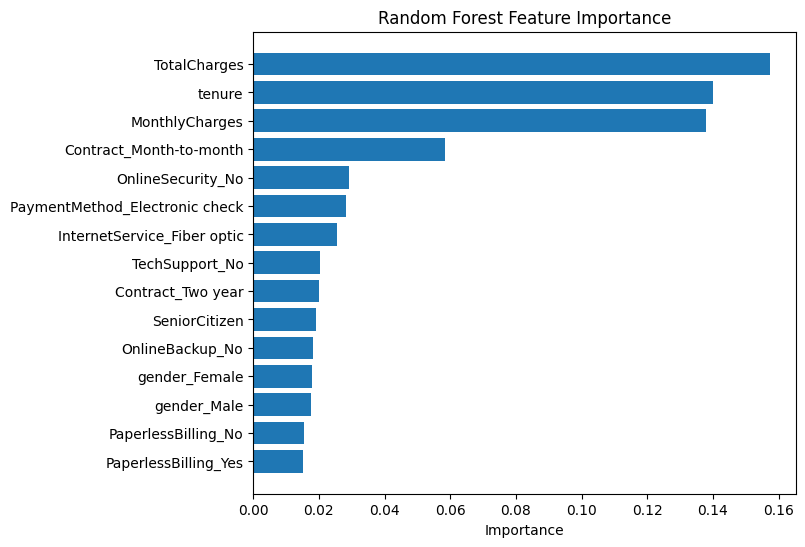

In [11]:
plt.figure(figsize=(7,6))
plt.barh(rf_df["Feature"].head(15), rf_df["Importance"].head(15))
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

### Permutation Importance

Permutation importance is model-agnostic ranking based on performance drop when we randomise any feature. If the performance drops for a feature, then that particular feature is more important.

In [12]:
logreg_pipe = logreg_l1  # reuse fitted L1 logistic model pipeline

# transform test data (preprocess part of pipeline) to use in permutation importance
X_test_transformed = logreg_pipe.named_steps["preprocess"].transform(X_test)

perm_log = permutation_importance(estimator=logreg_pipe.named_steps["model"],  # logistic model
                                  X=X_test_transformed, y=y_test, scoring="roc_auc",
                                  n_repeats=10, random_state=1)

# Extract transformed feature names
feature_names_out = logreg_pipe.named_steps["preprocess"].get_feature_names_out()

perm_log_df = pd.DataFrame({"Feature": feature_names_out, "Importance Mean": perm_log.importances_mean,
                            "Importance Std": perm_log.importances_std}).sort_values("Importance Mean", ascending=False)

perm_log_df.head(20)

,Feature,Importance Mean,Importance Std
1,num__tenure,0.201498,0.013173
38,cat__Contract_Two year,0.034661,0.005327
3,num__TotalCharges,0.029428,0.005230
31,cat__StreamingTV_No internet service,0.018082,0.003077
37,cat__Contract_One year,0.012459,0.001308
15,cat__InternetService_DSL,0.006381,0.001876
29,cat__TechSupport_Yes,0.004039,0.001023
43,cat__PaymentMethod_Electronic check,0.003975,0.001468
20,cat__OnlineSecurity_Yes,0.003346,0.001196
39,cat__PaperlessBilling_No,0.002956,0.000917


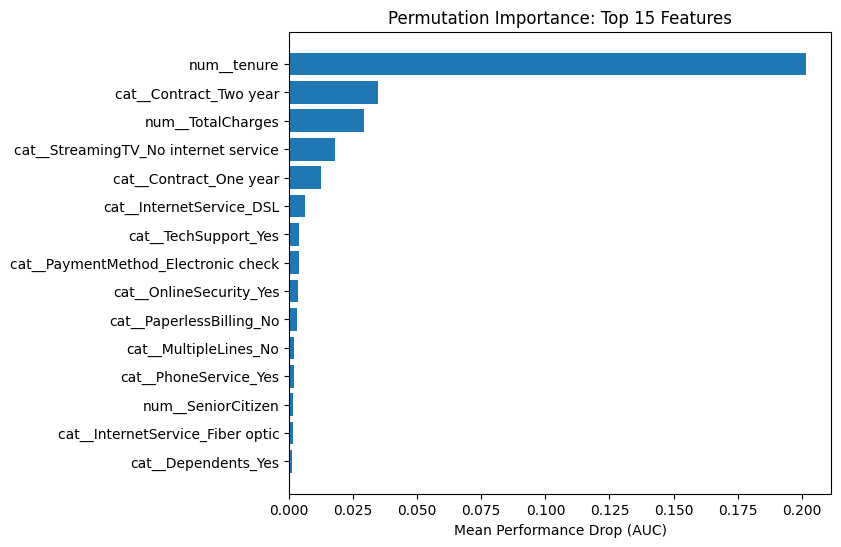

In [13]:
top_k = 15
plt.figure(figsize=(7,6))
plt.barh(perm_log_df["Feature"].head(top_k),perm_log_df["Importance Mean"].head(top_k))
plt.gca().invert_yaxis()
plt.title("Permutation Importance: Top 15 Features")
plt.xlabel("Mean Performance Drop (AUC)")
plt.show()

A feature whose randomisation substantially reduces AUC is considered predictively important. Unlike coefficient magnitudes, permutation importance captures interactions and scaling adjustments implicitly handled by preprocessing. 


Across the three models, we observe that features linked to billing and tenure appear most influential for churn detection, while some other inputs contribute minimally.

Embedded feature selection directly integrates the importance evaluation into model training.

- L1 logistic regression promotes sparsity and highlights the most predictive linear signals
- Random Forest can capture non-linear interactions and diverse relationships
- Permutation importance provides a fair performance-based ranking

The most reliable features are those consistently ranked highly across multiple embedded approaches.